In [2]:
!pip install roboflow
                

Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.com
   ---------------------------------------- 0.0/38.8 MB ? eta -:--:--
   ----- ---------------------------------- 5.2/38.8 MB 56.4 MB/s eta 0:00:01
   ----------- ---------------------------- 11.5/38.8 MB 28.8 MB/s eta 0:00:01
   ------------------ --------------------- 17.8/38.8 MB 30.4 MB/s eta 0:00:01
   -------------------- ------------------- 19.9/38.8 MB 25.7 MB/s eta 0:00:01
   ------------------------ --------------- 23.6/38.8 MB 23.0 MB/s eta 0:00:01
   --------------------------------- ------ 32.5/38.8 MB 28.1 MB/s eta 0:00:01
   ------------------------------------ --- 35.7/38.8 MB 27.0 MB/s eta 0:00:01
   ---------------------------------------- 38.8/38.8 MB 25.2 MB/s  0:00:01
   ---------------------------------------- 0.0/1.9 MB ? eta -:--:--
   ---------------------------------------- 1.9/1.9 MB 73.8 MB/s  0:00:00
   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   --------------


[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [21]:
from roboflow import Roboflow
rf = Roboflow(api_key="sS14JXKvOCoWLdvY3CO9")
project = rf.workspace("yolo-y7jtn").project("ppe-btied")
version = project.version(1)
dataset = version.download("yolov8")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to ppe-1 in yolov8:: 100%|██████████| 2030/2030 [00:01<00:00, 1989.71it/s]


In [23]:
import os
print(os.listdir('.'))

['Dataset', 'Main_file.ipynb', 'Renv']


In [25]:
import os
import shutil

folder = 'Dataset'

os.makedirs(f'{folder}/valid/images', exist_ok=True)
os.makedirs(f'{folder}/valid/labels', exist_ok=True)

train_imgs = os.listdir(f'{folder}/train/images')
val_imgs = train_imgs[:int(len(train_imgs) * 0.2)]

for img in val_imgs:
    shutil.copy(
        f'{folder}/train/images/{img}',
        f'{folder}/valid/images/{img}'
    )
    label = img.rsplit('.', 1)[0] + '.txt'
    src = f'{folder}/train/labels/{label}'
    if os.path.exists(src):
        shutil.copy(src, f'{folder}/valid/labels/{label}')

print(f"Valid set ready! {len(val_imgs)} images copy ho gayi")

Valid set ready! 202 images copy ho gayi


In [26]:
folder = 'Dataset'

yaml_content = """names:
- glasses
- gloves
- helmet
- mask
- vest
nc: 5
train: train/images
val: valid/images
"""

with open(f'{folder}/data.yaml', 'w') as f:
    f.write(yaml_content.strip())

print("data.yaml ready!")

data.yaml ready!


In [29]:
import sys
!{sys.executable} -m pip install ultralytics

Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.com



[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [31]:
import sys
!{sys.executable} -m pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118

Looking in indexes: https://download.pytorch.org/whl/cu118, https://pypi.ngc.nvidia.com
INFO: pip is looking at multiple versions of torchaudio to determine which version is compatible with other requirements. This could take a while.
   ---------------------------------------- 0.0/5.5 MB ? eta -:--:--
   --- ------------------------------------ 0.5/5.5 MB 5.2 MB/s eta 0:00:01
   ---------------------------------------- 5.5/5.5 MB 19.9 MB/s  0:00:00
   ---------------------------------------- 0.0/2.8 GB ? eta -:--:--
   ---------------------------------------- 0.0/2.8 GB 68.7 MB/s eta 0:00:41
   ---------------------------------------- 0.0/2.8 GB 47.0 MB/s eta 0:01:00
   ---------------------------------------- 0.0/2.8 GB 53.9 MB/s eta 0:00:52
    --------------------------------------- 0.0/2.8 GB 51.1 MB/s eta 0:00:55
    --------------------------------------- 0.0/2.8 GB 46.7 MB/s eta 0:01:00
    --------------------------------------- 0.1/2.8 GB 45.0 MB/s eta 0:01:02
    -----------

  You can safely remove it manually.
  You can safely remove it manually.


In [1]:
from ultralytics import YOLO

model = YOLO('yolov8s.pt')  # n ki jagah s — thoda bada model

results = model.train(
    data='Dataset/data.yaml',
    epochs=50,        # 30 ki jagah 50
    imgsz=640,
    batch=16,
    name='ppe_run_v2',
    device='0',
    patience=15
)

Ultralytics 8.4.51  Python-3.13.7 torch-2.7.1+cu118 CUDA:0 (NVIDIA GeForce RTX 4060 Laptop GPU, 8188MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=Dataset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=ppe_run_v2-3, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True,

In [3]:
import cv2
from ultralytics import YOLO
import PIL.Image
import io
import IPython.display as display

model = YOLO("runs/detect/ppe_run-2/weights/best.pt")
model.to('cuda')

cap = cv2.VideoCapture(0)
cap.set(cv2.CAP_PROP_FRAME_WIDTH, 640)
cap.set(cv2.CAP_PROP_FRAME_HEIGHT, 480)

print("Camera start — Press Stop button to stop")

try:
    while True:
        ret, frame = cap.read()
        if not ret:
            print("Camera not found!")
            break

        results = model(frame, conf=0.75, verbose=False, device='0',)
        annotated = results[0].plot()
        annotated_rgb = cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB)

        img = PIL.Image.fromarray(annotated_rgb)
        buf = io.BytesIO()
        img.save(buf, format='JPEG')
        buf.seek(0)

        display.clear_output(wait=True)
        display.display(PIL.Image.open(buf))

except KeyboardInterrupt:
    print("Camera stop!")
finally:
    cap.release()
    print("Camera released!")

Camera stop!
Camera released!


Ultralytics 8.4.51  Python-3.13.7 torch-2.7.1+cu118 CUDA:0 (NVIDIA GeForce RTX 4060 Laptop GPU, 8188MiB)
Model summary (fused): 73 layers, 3,006,623 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access  (ping: 0.00.0 ms, read: 648.7204.6 MB/s, size: 49.8 KB)
val: Scanning C:\Users\_Hub_\Desktop\Virender5\Dataset\valid\labels.cache... 202 images, 9 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 202/202 65.2Mit/s 0.0s
val: C:\Users\_Hub_\Desktop\Virender5\Dataset\valid\images\160616-Z-FF793-005_JPG_jpg.rf.1fd5d6c56170e8dae011dd128a2bba5d.jpg: 1 duplicate labels removed
val: C:\Users\_Hub_\Desktop\Virender5\Dataset\valid\images\428_png_jpg.rf.2fa56b4e4ee331c1c80071e41299838c.jpg: 1 duplicate labels removed
val: C:\Users\_Hub_\Desktop\Virender5\Dataset\valid\images\586_png_jpg.rf.7e8fab7d2212975a0c5136f31a099dea.jpg: 1 duplicate labels removed
WARNING Box and segment counts should be equal, but got len(segments) = 685, len(boxes) = 694. To resolve this only boxes will be used and all segm

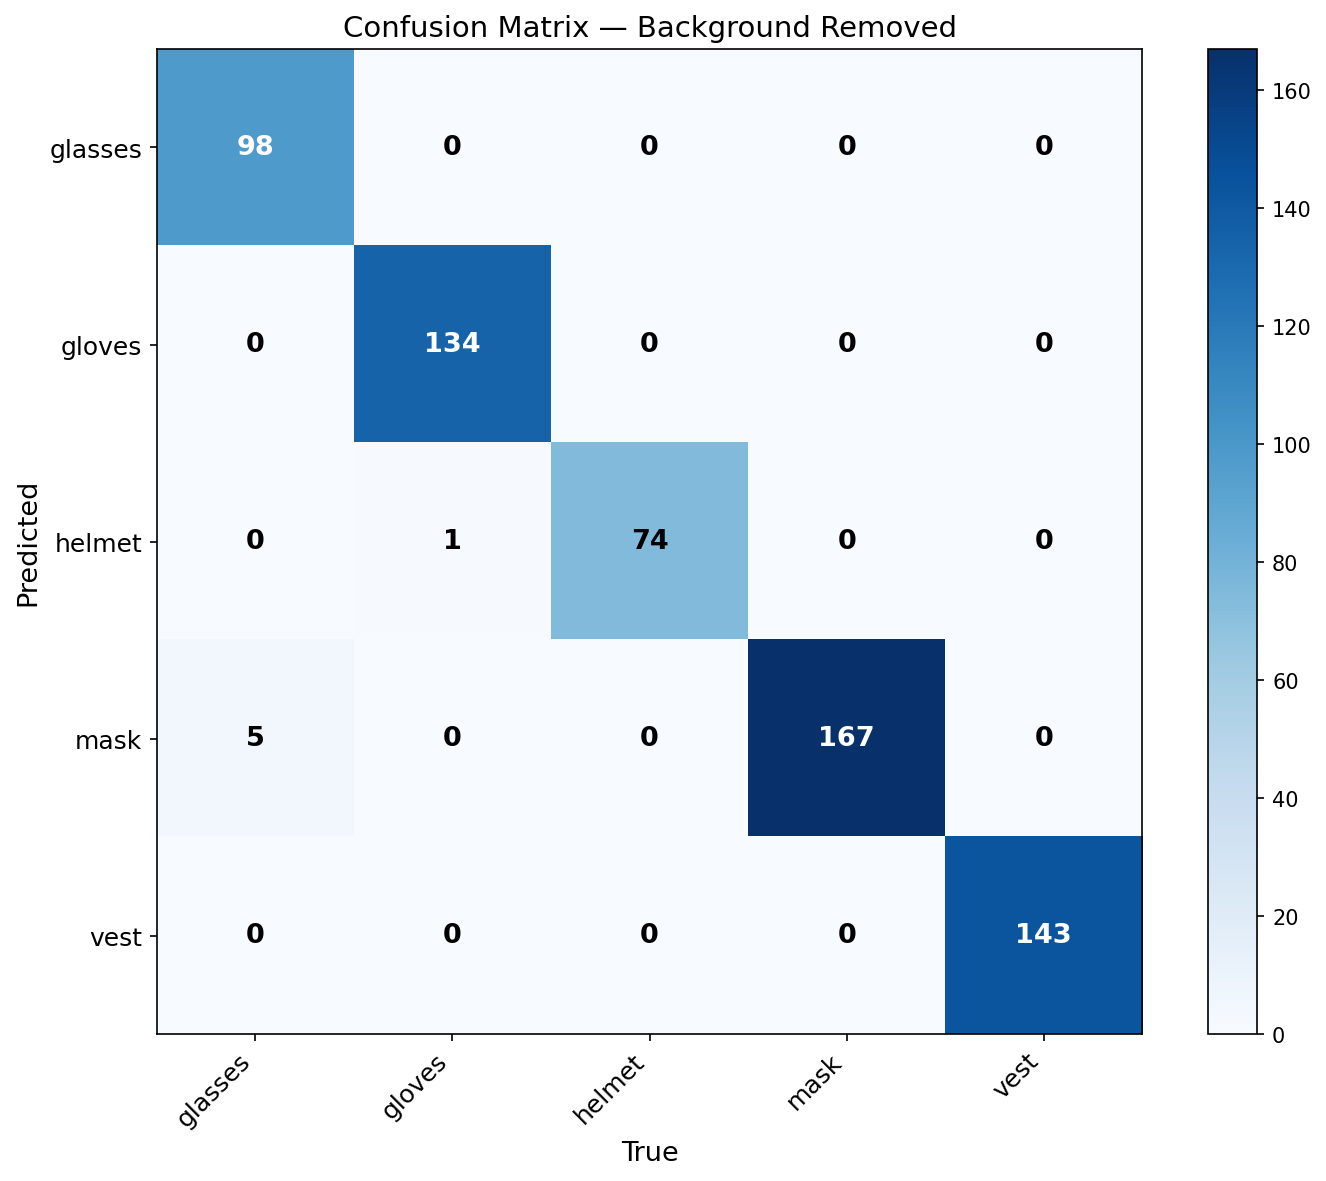

Done!


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO
from IPython.display import Image, display

model = YOLO("runs/detect/ppe_run-2/weights/best.pt")
metrics = model.val(data='Dataset/data.yaml', device='0', verbose=False)

cm = metrics.confusion_matrix.matrix
classes = ['glasses', 'gloves', 'helmet', 'mask', 'vest']
cm_no_bg = cm[:5, :5].astype(int)

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(cm_no_bg, cmap='Blues')
plt.colorbar(im, ax=ax)

ax.set_xticks(range(5))
ax.set_yticks(range(5))
ax.set_xticklabels(classes, rotation=45, ha='right', fontsize=12)
ax.set_yticklabels(classes, fontsize=12)

for i in range(5):
    for j in range(5):
        val = cm_no_bg[i, j]
        color = 'white' if val > cm_no_bg.max()/2 else 'black'
        ax.text(j, i, str(val), ha='center', va='center',
                color=color, fontsize=13, fontweight='bold')

ax.set_xlabel('True', fontsize=13)
ax.set_ylabel('Predicted', fontsize=13)
ax.set_title('Confusion Matrix — Background Removed', fontsize=14)

plt.tight_layout()
plt.savefig('confusion_matrix_no_bg.png', dpi=150, bbox_inches='tight')
plt.close()

display(Image(filename='confusion_matrix_no_bg.png', width=800))
print("Done!")